In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd 
import base64
import os 
import sys 
import time 


In [4]:
root_dir= os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(root_dir)
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver
from e2b_code_interpreter import Sandbox

In [6]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
checkpointer = InMemorySaver()
sbx = Sandbox.create(timeout=1*60)
response = sbx.run_code('print(5+8)')
response

Execution(Results: [], Logs: Logs(stdout: ['13\n'], stderr: []), Error: None)

In [7]:
response = sbx.run_code('print(0+8)')
response

Execution(Results: [], Logs: Logs(stdout: ['8\n'], stderr: []), Error: None)

In [8]:
import matplotlib.pyplot as plt 
import random

    Year  Car_Price_USD
0   2010          21840
1   2011          38037
2   2012          37080
3   2013          43113
4   2014          48232
5   2015          36279
6   2016          20583
7   2017          15487
8   2018          16449
9   2019          41969
10  2020          44783
11  2021          39818
12  2022          47089
13  2023          36671
14  2024          34863


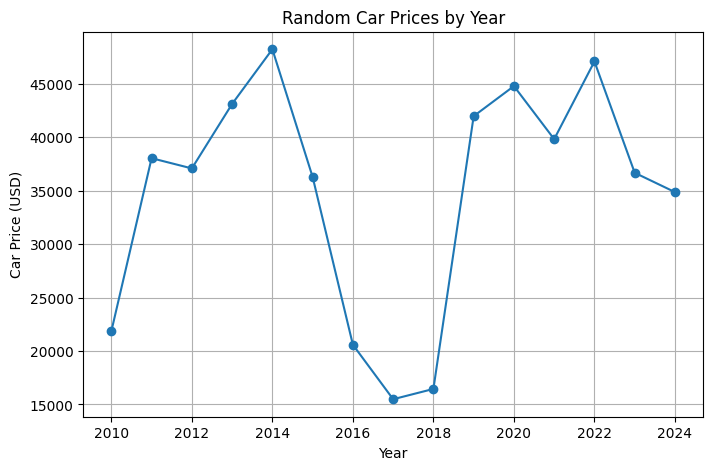

In [9]:
years = list(range(2010, 2025))

# Generate random car prices
prices = [random.randint(15000, 50000) for _ in years]

# Create pandas DataFrame
data = pd.DataFrame({
    "Year": years,
    "Car_Price_USD": prices
})

# Print dataset
print(data)

# Plot the data
plt.figure(figsize=(8,5))
plt.plot(data["Year"], data["Car_Price_USD"], marker="o")

plt.title("Random Car Prices by Year")
plt.xlabel("Year")
plt.ylabel("Car Price (USD)")
plt.grid(True)

plt.show()

In [10]:
code = '''
import pandas as pd
import matplotlib.pyplot as plt
import random
years = list(range(2010, 2025))

# Generate random car prices
prices = [random.randint(15000, 50000) for _ in years]

# Create pandas DataFrame
data = pd.DataFrame({
    "Year": years,
    "Car_Price_USD": prices
})

# Print dataset
print(data)

# Plot the data
plt.figure(figsize=(8,5))
plt.plot(data["Year"], data["Car_Price_USD"], marker="o")

plt.title("Random Car Prices by Year")
plt.xlabel("Year")
plt.ylabel("Car Price (USD)")
plt.grid(True)

plt.show()
'''

In [11]:
sbx = Sandbox.create(timeout=4*60)
response = sbx.run_code(code)
response

Execution(Results: [Result(<Figure size 800x500 with 1 Axes>)], Logs: Logs(stdout: ['    Year  Car_Price_USD\n0   2010          43142\n1   2011          31971\n2   2012          21321\n3   2013          26132\n4   2014          39300\n5   2015          49162\n6   2016          27186\n7   2017          42349\n8   2018          25567\n9   2019          40213\n10  2020          30821\n11  2021          45974\n12  2022          49590\n13  2023          40461\n14  2024          44827\n'], stderr: []), Error: None)

In [12]:
response.results[0].png

'...'

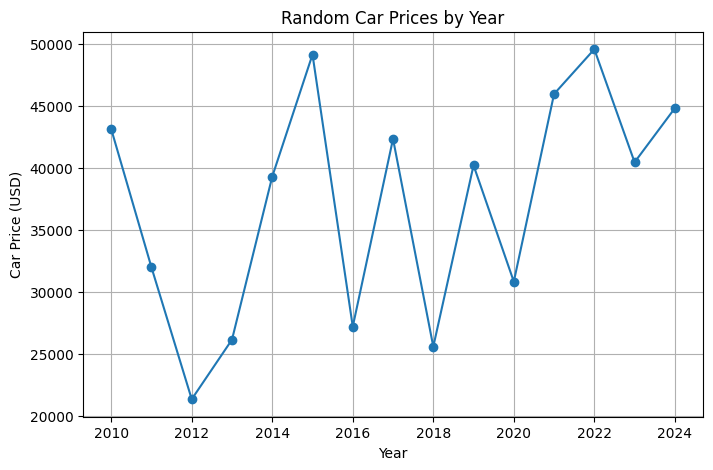

In [13]:
response.results[0]

In [14]:
def get_info(file_path):
   if file_path.endswith('.csv'):
        df = pd.read_csv(file_path, nrows = 3)
   else:
         df = pd.read_excel(file_path, nrows=3)

   return f"columns : {list(df.columns)} \n info : {df.to_string()}"


In [15]:
sbx = Sandbox.create(timeout=4*60)

In [16]:
@tool
def upload_file(filename = str):
    '''    
    Uploads a local file from ./data to the sandbox environment.
    Checks if the file exists locally and writes it to sandbox.
    Return'''
    filename = filename.lstrip('.').lstrip('/').lstrip('\\')
    file_path = f'../data/{filename}'
    if not os.path.exists(file_path):
        return f"Error: File not found {file_path}"
    with open(file_path, 'rb') as f :
        sandbox_file = sbx.files.write(f'/data/{file_path}',f)
        #info = get_info(sandbox_file)
    return f"File uploaded to sandbox  \nFile path {sandbox_file.path}"

In [17]:
upload_file.invoke("google_2024.xlsx")

'File uploaded to sandbox  \nFile path /data/../data/google_2024.xlsx'

In [18]:
get_info(file_path=r'F:\WORK\GENAI\ai-agents\Ai-Travel-Planner\data\apple_2024.xlsx')

"columns : ['APPLE INC. - FINANCIAL STATEMENTS 2024', 'Unnamed: 1'] \n info :   APPLE INC. - FINANCIAL STATEMENTS 2024   Unnamed: 1\n0                                    NaN          NaN\n1       BALANCE SHEET (as of 2024-09-30)          NaN\n2                                   Item  Value (USD)"

In [19]:
r = ['num', 'dfjkds']
p = "\n".join(r)
print(p)

num
dfjkds


In [20]:
@tool 
def run_code(code:str):
    '''
    executes python code in sandbox 
    
    args: 
     code : valid python code which is executable 

    returns:
     execution result  
    
    '''
    print("running sandbox code")

    execution = sbx.run_code(code)

    if execution.error :
        return f"Error occured name : {execution.error.name} value : {execution.error.value}"
    
    os.makedirs('images', exist_ok=True)
    

    output = []
    time = int(time.time())
    output.append(str(execution))
    
    for i,result in enumerate(execution.results):

      if result.png:
        file_name = f".images/{time}_no_{i}.png"

        with open (file_name, 'wb') as f :
           f.write(base64.b64decode(result.png))
           
        output.append (f"chart saved to {file_name}")

    return "\n".join(output) if output else "Code executed .No output was returned"    



In [26]:
root_dir = os.path.dirname(os.getcwd())
sys.path.append(root_dir)
print(root_dir)

f:\WORK\GENAI\ai-agents\Ai-Travel-Planner


In [27]:
from scripts import prompts
from langchain.agents.middleware import FilesystemFileSearchMiddleware

agent = create_agent(

    model = llm,
    system_prompt=prompts.CODE_EXECUTION_PROMPT,
    tools=[upload_file, run_code],
    middleware=[FilesystemFileSearchMiddleware(
        root_path='../data',
        use_ripgrep=True,
        max_file_size_mb=500
     )
    ]
) 


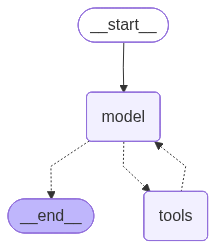

In [28]:
agent